<a href="https://colab.research.google.com/github/abin0001/Anveshion_project/blob/master/Medical_plant_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ***Medicinal Plant Classification***


In [1]:
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


## **Importing Required Packages**

In [4]:
#Importing the Libraries
import os  #To access file directory
import cv2 # To handle the images
import matplotlib.pyplot as plt # To visualise the data
import pandas as pd # To handle the dataframes
import numpy as np # to handle with arrays
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input # Pretrained Model
from tensorflow.keras import layers, models, optimizers # For NueralNetworks
from tensorflow.keras.callbacks import TensorBoard  #To analyse the model Performance
from ast import literal_eval # To Evaluate string  fro the arrays
import pickle #To create a image dataset

### **Creating our own dataset**

```python
path = "/content/drive/MyDrive/Anveshon project/Plants Images/cropped images Resized Images"
trg_path="/content/drive/MyDrive/Anveshon project/Plants Images"

class CreateImageDataset:
    def __init__(self, dir_path, dir_des_path,file_name):
        self.dataframe = []
        self.dataset_name=file_name
        self.dir_path = dir_path
        self.dir_des_path = dir_des_path
        self.class_list = os.listdir(self.dir_path)

    def finish(self):
        print('Dataset created successfully')

    def Download(self):
        print('Dataset Download successfully')

    def create_csv_dataset(self):
        for self.class_folder in self.class_list:
            self.class_path = os.path.join(self.dir_path, self.class_folder)
            if os.path.isdir(self.class_path):
                for self.img_filename in os.listdir(self.class_path):
                    self.img_path = os.path.join(self.class_path, self.img_filename)
                    self.img = cv2.imread(self.img_path)
                    self.dataframe.append([self.img, self.class_folder])

        self.finish()

    def Download_pickle_data(self):
        imgDataset = pd.DataFrame(self.dataframe, columns=['Image', 'Target'])
        file_ = open(os.path.join(self.dir_des_path,self.dataset_name), 'wb')
        pickle.dump(imgDataset, file_)
        file_.close()
        self.Download()


if __name__ == "__main__":
    source_folder = path
    des_path=trg_path
    name="Dataset.pickle"
    dataset_creator = CreateImageDataset(source_folder,des_path,name)  # You can provide a destination path if needed
    dataset_creator.create_csv_dataset()
    dataset_creator.Download_pickle_data()

  ```

In [7]:
data_=open('/content/drive/MyDrive/Anveshon project/Plants Images/dataset.pickel','rb')
data=pickle.load(data_)

In [8]:
data.head()

,Image,Target
0,"[[[14, 41, 38], [30, 57, 54], [42, 69, 66], [1...",Neem
1,"[[[197, 198, 188], [198, 199, 189], [199, 200,...",Neem
2,"[[[160, 171, 179], [161, 172, 180], [162, 173,...",Neem
3,"[[[176, 179, 177], [171, 174, 172], [166, 169,...",Neem
4,"[[[149, 190, 183], [142, 184, 177], [132, 182,...",Neem


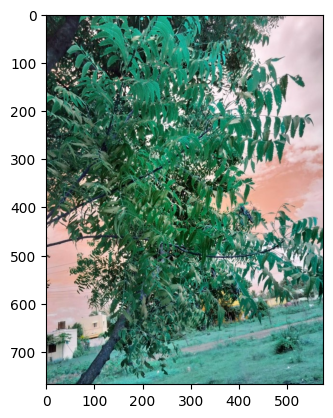

In [9]:
plt.imshow(data['Image'].iloc[0])

## **Error with csv dataset**

#### **Trying to show frist image from csv dataset**
**code**

```python
# convert pickle data to csv
data.to_csv('/content/drive/MyDrive/Anveshon project/Plants Images/dataset.csv')

#reading the csv Data
data.to_csv('/content/drive/MyDrive/Anveshon project/Plants Images/dataset.csv')

#checking the Dataset
plt.imshow(data['Image'].iloc[0])
```
**Output:**
```python
---------------------------------------------------------------------------

TypeError                                 Traceback (most recent call last)

<ipython-input-16-2f6e53d0650e> in <cell line: 1>()
----> 1 plt.imshow(data['Image'].iloc[0])

3 frames

/usr/local/lib/python3.10/dist-packages/matplotlib/image.py in set_data(self, A)
    699         if (self._A.dtype != np.uint8 and
    700                 not np.can_cast(self._A.dtype, float, "same_kind")):
--> 701             raise TypeError("Image data of dtype {} cannot be converted to "
    702                             "float".format(self._A.dtype))
    703

TypeError: Image data of dtype <U629 cannot be converted to float
```
#### **Checking the Image pixel Values**
**code**

```python
data["Image"].iloc[0]
# This is formatted as code
```
**output:**

```python
'[[[ 14  41  38]\n  [ 30  57  54]\n  [ 42  69  66]\n  ...\n  [216 192 202]\n  [214 193 202]\n  [214 193 202]]\n\n [[ 20  44  42]\n  [ 73  97  95]\n  [ 78 102 100]\n  ...\n  [216 192 202]\n  [214 193 202]\n  [215 194 203]]\n\n [[ 10  31  29]\n  [ 50  71  69]\n  [ 82 103 101]\n  ...\n  [216 192 202]\n  [215 194 203]\n  [215 194 203]]\n\n ...\n\n [[113 140 137]\n  [ 64  91  88]\n  [ 78 105 102]\n  ...\n  [ 57 123 118]\n  [ 66 130 125]\n  [ 60 124 119]]\n\n [[ 94 121 117]\n  [ 69  96  92]\n  [102 126 124]\n  ...\n  [ 38 104  99]\n  [ 61 124 122]\n  [ 52 115 113]]\n\n [[ 73 100  96]\n  [ 89 116 112]\n  [113 137 135]\n  ...\n  [ 49 115 110]\n  [ 61 124 122]\n  [ 58 121 119]]]'
```

**Reason:**
```
TypeError: Image data of dtype <U629 cannot be converted to float. So The image pixles are in string.
```

#### **Trying to Convert the sring value to float**

**code**
```python
plt.imshow(np.array(data['Image'].iloc[0]).astype(float))
```

**output**
```python
---------------------------------------------------------------------------

ValueError                                Traceback (most recent call last)

<ipython-input-17-4264238dbf8a> in <cell line: 1>()
----> 1 plt.imshow(np.array(data['Image'].iloc[0]).astype(float))

ValueError: could not convert string to float: '[[[ 14  41  38]\n  [ 30  57  54]\n  [ 42  69  66]\n  ...\n  [216 192 202]\n  [214 193 202]\n  [214 193 202]]\n\n [[ 20  44  42]\n  [ 73  97  95]\n  [ 78 102 100]\n  ...\n  [216 192 202]\n  [214 193 202]\n  [215 194 203]]\n\n [[ 10  31  29]\n  [ 50  71  69]\n  [ 82 103 101]\n  ...\n  [216 192 202]\n  [215 194 203]\n  [215 194 203]]\n\n ...\n\n [[113 140 137]\n  [ 64  91  88]\n  [ 78 105 102]\n  ...\n  [ 57 123 118]\n  [ 66 130 125]\n  [ 60 124 119]]\n\n [[ 94 121 117]\n  [ 69  96  92]\n  [102 126 124]\n  ...\n  [ 38 104  99]\n  [ 61 124 122]\n  [ 52 115 113]]\n\n [[ 73 100  96]\n  [ 89 116 112]\n  [113 137 135]\n  ...\n  [ 49 115 110]\n  [ 61 124 122]\n  [ 58 121 119]]]'
```
**code**
```python
from ast import literal_eval
data['Image'] = data['Image'].apply(literal_evl)
```
**output**
```python
Traceback (most recent call last):

  File "/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)

  File "<ipython-input-21-3ce86cf45328>", line 1, in <cell line: 1>
    data['Image'] = data['Image'].apply(literal_eval)

  File "/usr/local/lib/python3.10/dist-packages/pandas/core/series.py", line 4771, in apply
    return SeriesApply(self, func, convert_dtype, args, kwargs).apply()

  File "/usr/local/lib/python3.10/dist-packages/pandas/core/apply.py", line 1123, in apply
    return self.apply_standard()

  File "/usr/local/lib/python3.10/dist-packages/pandas/core/apply.py", line 1174, in apply_standard
    mapped = lib.map_infer(

  File "pandas/_libs/lib.pyx", line 2924, in pandas._libs.lib.map_infer

  File "/usr/lib/python3.10/ast.py", line 64, in literal_eval
    node_or_string = parse(node_or_string.lstrip(" \t"), mode='eval')

  File "/usr/lib/python3.10/ast.py", line 50, in parse
    return compile(source, filename, mode, flags,

  File "<unknown>", line 1
    [[[ 14  41  38]
        ^
SyntaxError: invalid syntax. Perhaps you forgot a comma?
```




# **Building Vgg16 model**

In [ ]:
# # Build VGG-16 model

Vgg16_base_mdl = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# model = models.Sequential()
# model.add(base_model)
# model.add(layers.Flatten())
# model.add(layers.Dense(256, activation='relu'))
# model.add(layers.Dropout(0.5))
# model.add(layers.Dense(Num_classes, activation='softmax'))

# # Compile the model
# model.compile(optimizer=optimizers.Adam(lr=0.0001),
#               loss='categorical_crossentropy',
#               metrics=['accuracy'])

# # Train the model
# model.fit(x_train,y_train);

58889256/58889256 [==============================] - 0s 0us/step


In [ ]:
for layer in Vgg16_base_mdl.layers:
    layer.trainable = False